# SaltySeq EDA Panel Data

Panel-aware EDA for train (2015-2022) and holdout test (2023-2025).
All temporal transforms and diagnostics are location-isolated.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sns.set_theme(style='whitegrid', context='notebook')

def find_root() -> Path:
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / 'data' / 'splits' / 'train_2015_2022.csv').exists():
            return candidate
    raise FileNotFoundError('Cannot find project root with split artifacts')

ROOT = find_root()
SPLIT_DIR = ROOT / 'data' / 'splits'
TRAIN_PATH = SPLIT_DIR / 'train_2015_2022.csv'
HOLDOUT_PATH = SPLIT_DIR / 'holdout_test_2023_2025.csv'

train_df = pd.read_csv(TRAIN_PATH, parse_dates=['date']).sort_values(['location_id', 'date']).reset_index(drop=True)
holdout_df = pd.read_csv(HOLDOUT_PATH, parse_dates=['date']).sort_values(['location_id', 'date']).reset_index(drop=True)

print('train shape:', train_df.shape)
print('holdout shape:', holdout_df.shape)
print('locations:', sorted(train_df['location_id'].unique()))

train shape: (14610, 62)
holdout shape: (5480, 62)
locations: ['BT_BaTri', 'BT_BinhDai', 'BT_ChauThanh', 'BT_GiongTrom', 'BT_ThanhPhu']


## 1) Panel Integrity and Split Audit

In [2]:
def panel_summary(df: pd.DataFrame, name: str) -> pd.DataFrame:
    rows = len(df)
    cols = df.shape[1]
    key_unique = not df.duplicated(['location_id', 'date']).any()
    complete_pct = (1 - df.isna().sum().sum() / (rows * cols)) * 100
    pos_rate = df['is_stress_event'].mean() * 100 if 'is_stress_event' in df.columns else np.nan
    return pd.DataFrame([
        {
            'dataset': name,
            'rows': rows,
            'cols': cols,
            'start': df['date'].min().date().isoformat(),
            'end': df['date'].max().date().isoformat(),
            'locations': df['location_id'].nunique(),
            'key_unique': key_unique,
            'completeness_pct': round(complete_pct, 4),
            'stress_positive_rate_pct': round(pos_rate, 4),
        }
    ])

summary = pd.concat([
    panel_summary(train_df, 'train_2015_2022'),
    panel_summary(holdout_df, 'holdout_test_2023_2025')
], ignore_index=True)
display(summary)

loc_cov = train_df.groupby('location_id', as_index=False).agg(
    train_rows=('date', 'size'),
    train_start=('date', 'min'),
    train_end=('date', 'max')
)
loc_cov_h = holdout_df.groupby('location_id', as_index=False).agg(
    holdout_rows=('date', 'size'),
    holdout_start=('date', 'min'),
    holdout_end=('date', 'max')
)
loc_cov = loc_cov.merge(loc_cov_h, on='location_id', how='outer').sort_values('location_id')
display(loc_cov)

,dataset,rows,cols,start,end,locations,key_unique,completeness_pct,stress_positive_rate_pct
0,train_2015_2022,14610,62,2015-01-01,2022-12-31,5,True,99.5329,10.0548
1,holdout_test_2023_2025,5480,62,2023-01-01,2025-12-31,5,True,99.7610,12.8102


,location_id,train_rows,train_start,train_end,holdout_rows,holdout_start,holdout_end
0,BT_BaTri,2922,2015-01-01,2022-12-31,1096,2023-01-01,2025-12-31
1,BT_BinhDai,2922,2015-01-01,2022-12-31,1096,2023-01-01,2025-12-31
2,BT_ChauThanh,2922,2015-01-01,2022-12-31,1096,2023-01-01,2025-12-31
3,BT_GiongTrom,2922,2015-01-01,2022-12-31,1096,2023-01-01,2025-12-31
4,BT_ThanhPhu,2922,2015-01-01,2022-12-31,1096,2023-01-01,2025-12-31


## 2) Interpolation and Gap Audit

In [3]:
for name, df in [('train', train_df), ('holdout', holdout_df)]:
    print(f'=== {name.upper()} interpolation mix ===')
    if 'ndvi_interp_method' in df.columns:
        mix = (df['ndvi_interp_method'].value_counts(normalize=True) * 100).round(2)
        print(mix.to_string())
    if 'ndvi_gap_days' in df.columns:
        gap_desc = df['ndvi_gap_days'].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).round(2)
        print('ndvi_gap_days stats:\n', gap_desc.to_string())
    print()

if 'ndvi_interp_method' in train_df.columns:
    by_loc = (
        train_df.groupby(['location_id', 'ndvi_interp_method']).size()
        .reset_index(name='count')
        .sort_values(['location_id', 'count'], ascending=[True, False])
    )
    display(by_loc.head(30))

=== TRAIN interpolation mix ===
ndvi_interp_method
pchip       78.56
observed    21.44
ndvi_gap_days stats:
 count    14610.00
mean         4.48
std          2.85
min          0.00
50%          6.00
90%          7.00
95%          7.00
99%          7.00
max          7.00

=== HOLDOUT interpolation mix ===
ndvi_interp_method
pchip       74.69
observed    25.31
ndvi_gap_days stats:
 count    5480.00
mean        3.81
std         2.92
min         0.00
50%         4.00
90%         7.00
95%         7.00
99%         7.00
max        13.00



,location_id,ndvi_interp_method,count
1,BT_BaTri,pchip,2336
0,BT_BaTri,observed,586
3,BT_BinhDai,pchip,2283
2,BT_BinhDai,observed,639
5,BT_ChauThanh,pchip,2355
4,BT_ChauThanh,observed,567
7,BT_GiongTrom,pchip,2269
6,BT_GiongTrom,observed,653
9,BT_ThanhPhu,pchip,2234
8,BT_ThanhPhu,observed,688


## 3) ACF and PACF by Location

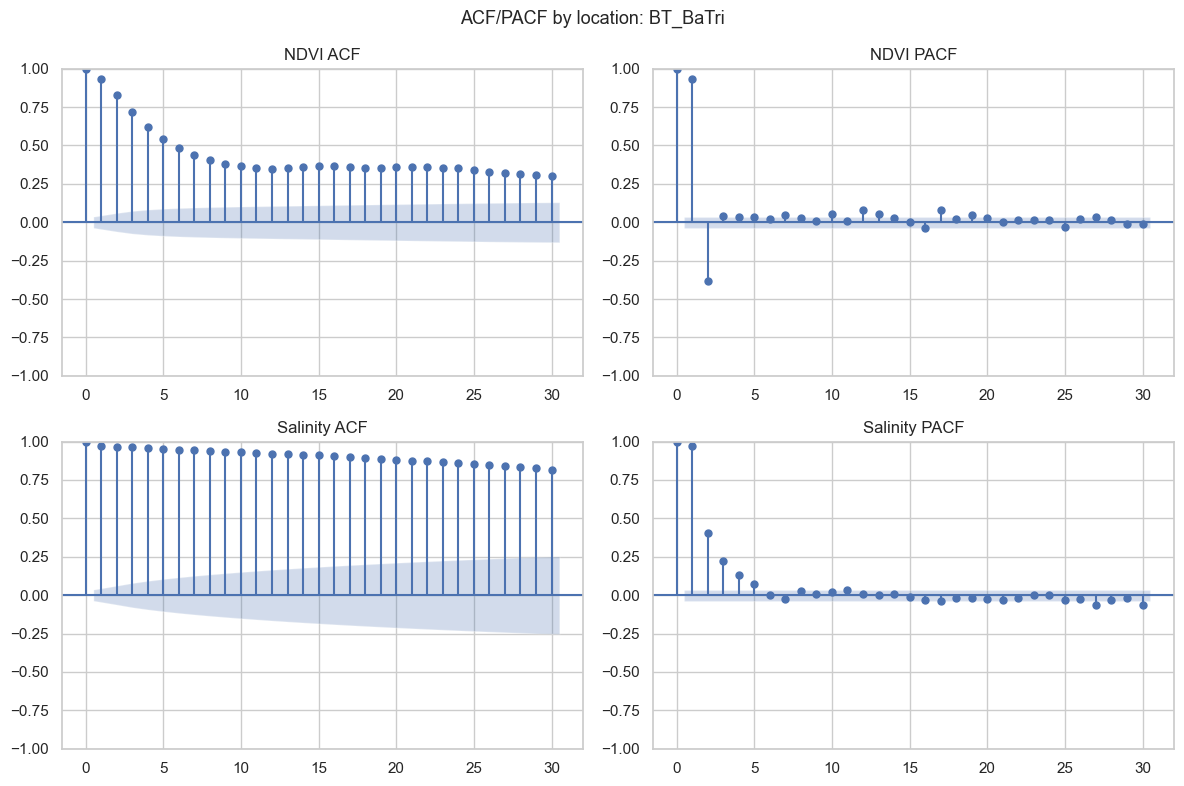

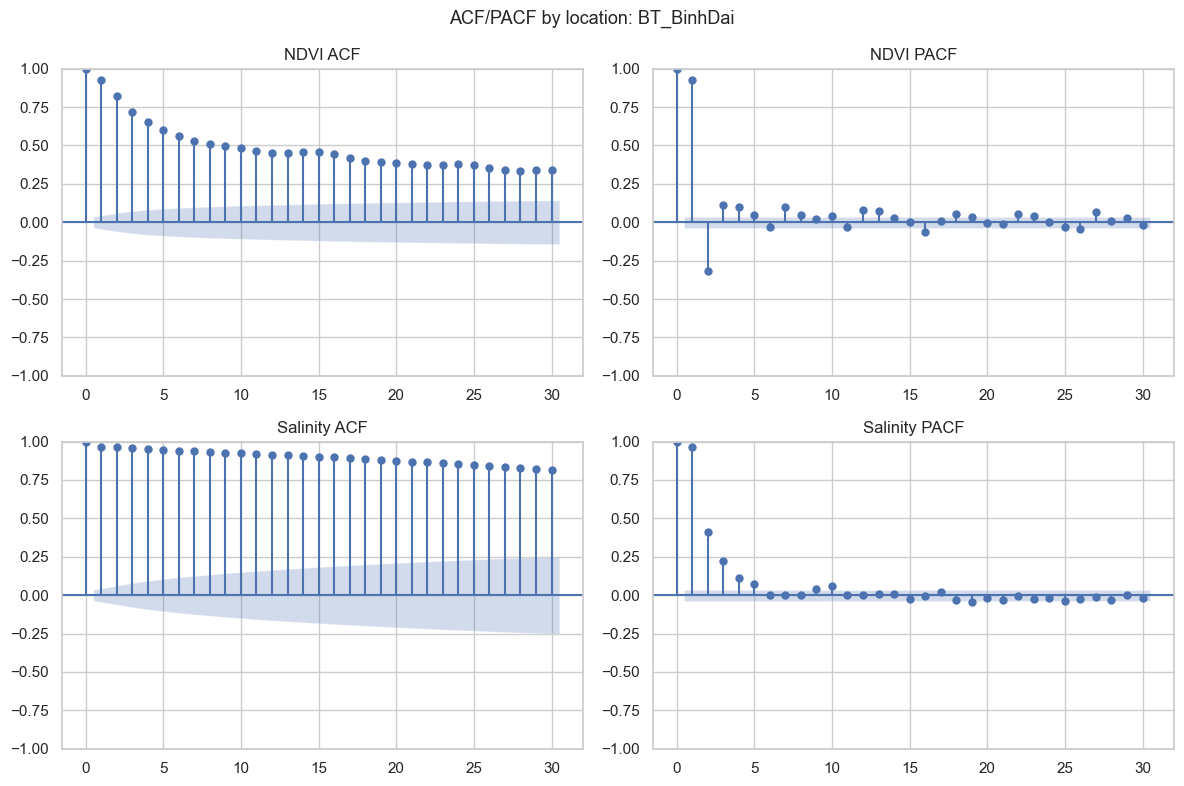

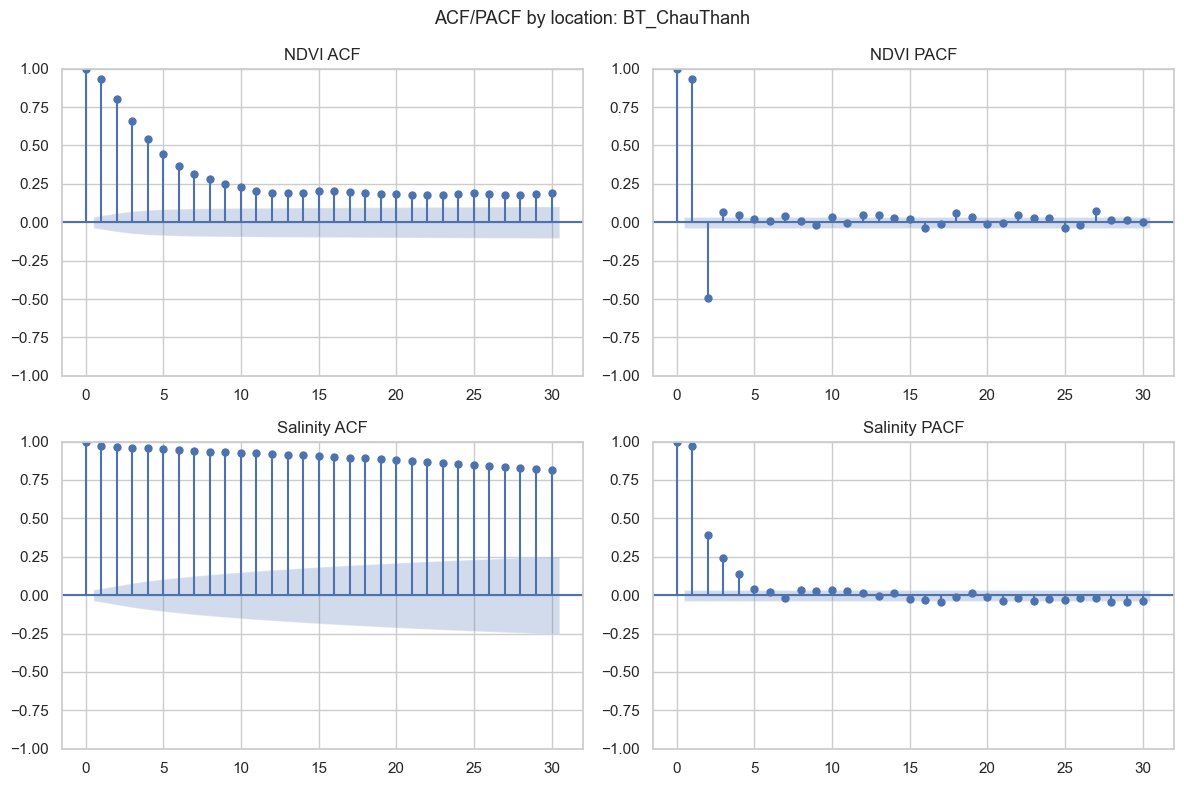

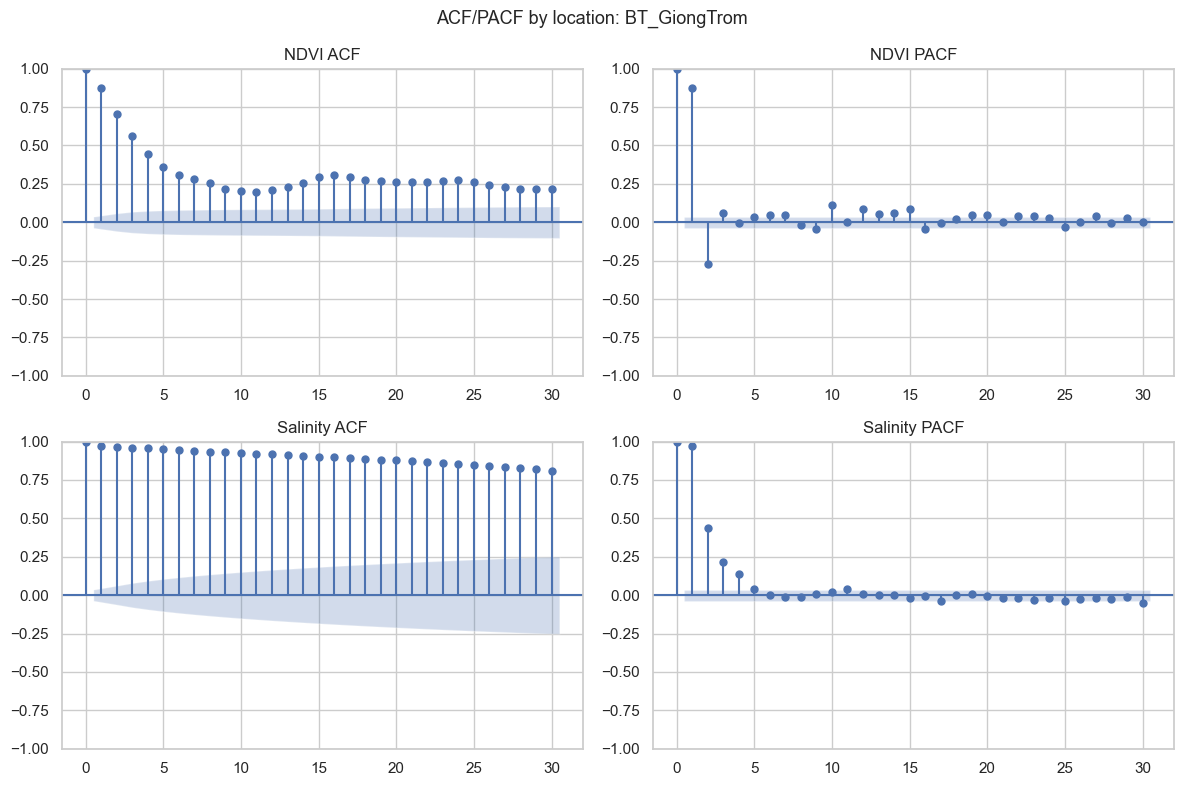

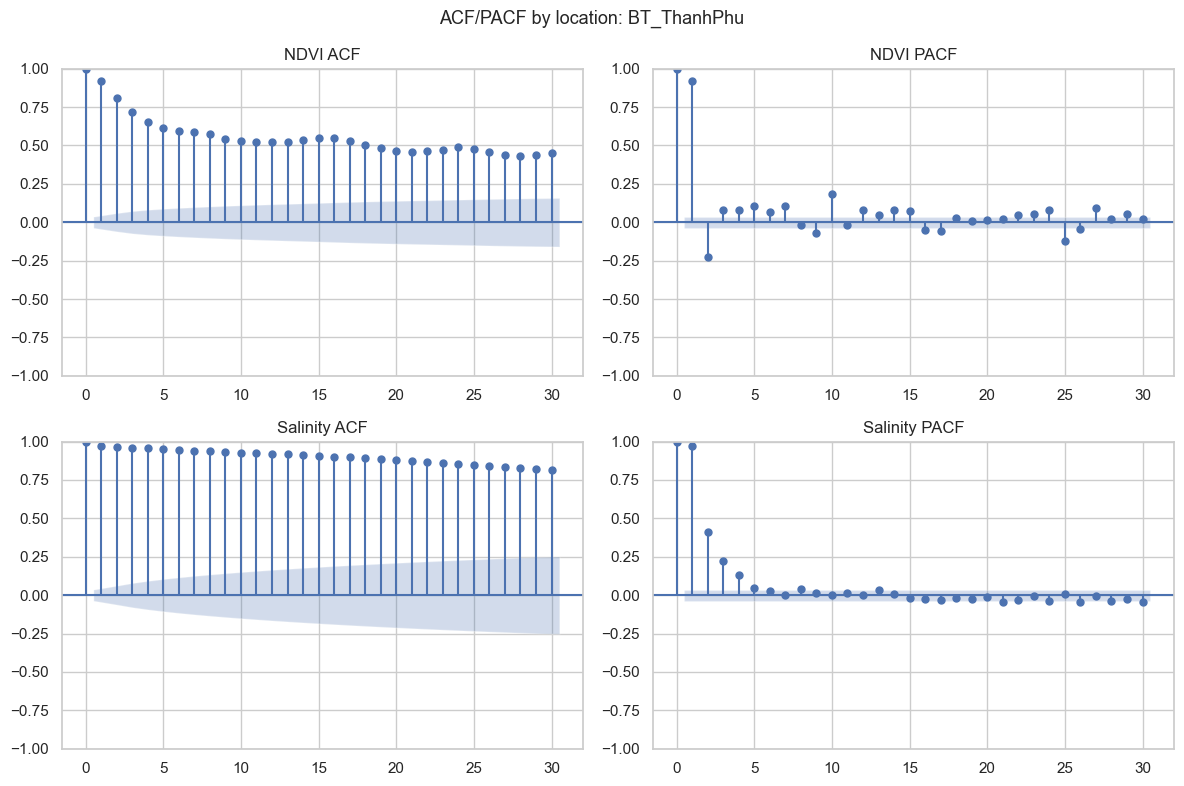

In [4]:
locations = sorted(train_df['location_id'].unique())

for loc in locations:
    loc_df = train_df[train_df['location_id'] == loc].sort_values('date').copy()
    ndvi_series = loc_df['ndvi'].dropna()
    sal_series = loc_df['salinity_psu'].dropna()

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f'ACF/PACF by location: {loc}', fontsize=13)

    plot_acf(ndvi_series, lags=30, ax=axes[0, 0])
    axes[0, 0].set_title('NDVI ACF')

    plot_pacf(ndvi_series, lags=30, ax=axes[0, 1], method='ywm')
    axes[0, 1].set_title('NDVI PACF')

    plot_acf(sal_series, lags=30, ax=axes[1, 0])
    axes[1, 0].set_title('Salinity ACF')

    plot_pacf(sal_series, lags=30, ax=axes[1, 1], method='ywm')
    axes[1, 1].set_title('Salinity PACF')

    plt.tight_layout()
    plt.show()

## 4) Granger Causality by Location (Salinity -> NDVI)

In [5]:
def make_stationary(series: pd.Series, alpha: float = 0.05) -> tuple[pd.Series, int, float]:
    x = series.dropna().astype(float)
    if len(x) < 30:
        return x, 0, np.nan

    try:
        p0 = adfuller(x, autolag='AIC')[1]
    except Exception:
        return x, 0, np.nan

    if p0 < alpha:
        return x, 0, p0

    x1 = x.diff().dropna()
    if len(x1) < 30:
        return x1, 1, np.nan

    try:
        p1 = adfuller(x1, autolag='AIC')[1]
    except Exception:
        p1 = np.nan
    return x1, 1, p1

rows = []
max_lag = 7

for loc in sorted(train_df['location_id'].unique()):
    loc_df = train_df[train_df['location_id'] == loc].sort_values('date')[['date', 'ndvi', 'salinity_psu']].copy()

    ndvi_s, ndvi_diff_order, ndvi_adf_p = make_stationary(loc_df['ndvi'])
    sal_s, sal_diff_order, sal_adf_p = make_stationary(loc_df['salinity_psu'])

    aligned = pd.concat([ndvi_s.rename('ndvi'), sal_s.rename('salinity_psu')], axis=1).dropna()

    if len(aligned) <= max_lag + 5:
        rows.append({
            'location_id': loc,
            'samples': len(aligned),
            'ndvi_diff_order': ndvi_diff_order,
            'sal_diff_order': sal_diff_order,
            'ndvi_adf_p': ndvi_adf_p,
            'sal_adf_p': sal_adf_p,
            'best_lag': np.nan,
            'min_pvalue': np.nan,
            'salinity_causes_ndvi': False,
        })
        continue

    try:
        test_df = aligned[['ndvi', 'salinity_psu']]
        gc = grangercausalitytests(test_df, maxlag=max_lag, verbose=False)
        pvals = {lag: gc[lag][0]['ssr_ftest'][1] for lag in gc}
        best_lag = min(pvals, key=pvals.get)
        min_p = pvals[best_lag]
    except Exception:
        best_lag = np.nan
        min_p = np.nan

    rows.append({
        'location_id': loc,
        'samples': len(aligned),
        'ndvi_diff_order': ndvi_diff_order,
        'sal_diff_order': sal_diff_order,
        'ndvi_adf_p': ndvi_adf_p,
        'sal_adf_p': sal_adf_p,
        'best_lag': best_lag,
        'min_pvalue': min_p,
        'salinity_causes_ndvi': bool(min_p < 0.05) if pd.notna(min_p) else False,
    })

granger_report = pd.DataFrame(rows).sort_values('location_id')
display(granger_report)

c:\Users\ADMINN\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\ADMINN\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\ADMINN\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\ADMINN\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\ADMINN\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print resul

,location_id,samples,ndvi_diff_order,sal_diff_order,ndvi_adf_p,sal_adf_p,best_lag,min_pvalue,salinity_causes_ndvi
0,BT_BaTri,2921,0,1,1.535938e-07,0.000000,1,0.418472,False
1,BT_BinhDai,2921,0,1,5.108577e-06,0.000000,1,0.670962,False
2,BT_ChauThanh,2922,0,0,4.282503e-08,0.005125,1,0.680358,False
3,BT_GiongTrom,2921,0,1,6.290018e-07,0.000000,7,0.049893,True
4,BT_ThanhPhu,2921,0,1,9.654199e-04,0.000000,2,0.133289,False


## 5) Final Readiness Checks

In [6]:
checks = pd.DataFrame([
    ['Train key unique', not train_df.duplicated(['location_id', 'date']).any(), 'Panel integrity'],
    ['Holdout key unique', not holdout_df.duplicated(['location_id', 'date']).any(), 'Panel integrity'],
    ['Train date range', train_df['date'].min().date().isoformat() == '2015-01-01' and train_df['date'].max().date().isoformat() == '2022-12-31', 'Split boundary'],
    ['Holdout date range', holdout_df['date'].min().date().isoformat() == '2023-01-01' and holdout_df['date'].max().date().isoformat() == '2025-12-31', 'Split boundary'],
    ['Location coverage match', set(train_df['location_id'].unique()) == set(holdout_df['location_id'].unique()), 'No spatial omission'],
], columns=['check', 'pass', 'comment'])

display(checks)

if checks['pass'].all():
    print('READY: panel split and diagnostics pass baseline integrity checks.')
else:
    print('NOT READY: at least one baseline check failed.')

,check,pass,comment
0,Train key unique,True,Panel integrity
1,Holdout key unique,True,Panel integrity
2,Train date range,True,Split boundary
3,Holdout date range,True,Split boundary
4,Location coverage match,True,No spatial omission


READY: panel split and diagnostics pass baseline integrity checks.
